In [18]:
from pathlib import Path
import math

import torch
from torch import Tensor
from torch import nn
from torch.nn import functional as F

from torch_geometric import nn as geometric_nn
from torch_geometric import data
from torch_geometric import loader
from torch_geometric import datasets

# from torch_scatter import scatter

import e3nn

import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

import numpy as np

In [2]:
train_md17 = datasets.MD17(root=Path(_dh[-1]) / "data/train/",
                           name="aspirin CCSD",
                           train=True)

In [3]:
len(train_md17)

1000

In [4]:
test_md17 = datasets.MD17(root=Path(_dh[-1]) / "data/test/",
                          name="aspirin CCSD",
                          train=False)
len(test_md17)

500

In [5]:
train_md17[0]

Data(pos=[21, 3], z=[21], energy=[1], force=[21, 3])

In [6]:
train_md17[0].force

tensor([[-38.7790,  -7.4491,  32.2437],
        [-46.7607,  28.0828,  -2.4308],
        [ 87.9273, -25.0825,  -3.8001],
        [ -4.9108,   4.4387,  16.9526],
        [-37.1069, -30.3190, -21.2231],
        [  6.2805,  17.9019, -13.4590],
        [ -9.7491,  74.5307, -43.8835],
        [-22.2231,  -8.7230,  41.1838],
        [ 18.3889,  21.6293,  50.3443],
        [ 14.6906, -43.0008,  18.8180],
        [ 17.8357,  -2.5351, -28.2878],
        [  7.6289,   3.9155,   8.1579],
        [-21.5278, -49.7304, -22.5369],
        [-10.1448,  24.5696, -14.0945],
        [ 14.9778,   7.3844,  -2.5014],
        [  6.2947, -51.2208,  43.7552],
        [-41.8874, -11.2726,  -9.1653],
        [ 22.9206,  21.1146, -43.9224],
        [  7.7661,  38.5220,  -0.3262],
        [ 26.9917,  -1.1146,   5.6660],
        [  1.3870, -11.6418, -11.4906]])

In [7]:
train_md17[0].pos

tensor([[ 2.1345, -0.9844, -0.1952],
        [ 0.7626,  0.9594, -1.6799],
        [ 2.6603, -0.4079, -1.3073],
        [ 1.9103,  0.3940, -2.1470],
        [-3.0302,  1.4954,  0.7197],
        [ 0.8494, -0.5509,  0.2844],
        [ 0.2384,  0.4735, -0.4044],
        [ 0.8979, -2.2764,  1.7301],
        [-2.3835,  0.4178, -1.4629],
        [-0.4762, -0.5291,  2.3393],
        [ 0.3930, -1.1902,  1.5380],
        [-2.1230,  0.9518, -0.3977],
        [-0.8047,  1.2862,  0.1105],
        [-0.4938, -1.1868,  3.0960],
        [ 2.5547, -1.8025,  0.3921],
        [ 0.3307,  1.8557, -2.3453],
        [ 3.8038, -0.4937, -1.4562],
        [ 2.2311,  0.5572, -3.1241],
        [-2.7089,  2.4847,  0.9269],
        [-4.1305,  1.4822,  0.4313],
        [-2.8741,  1.0032,  1.6995]])

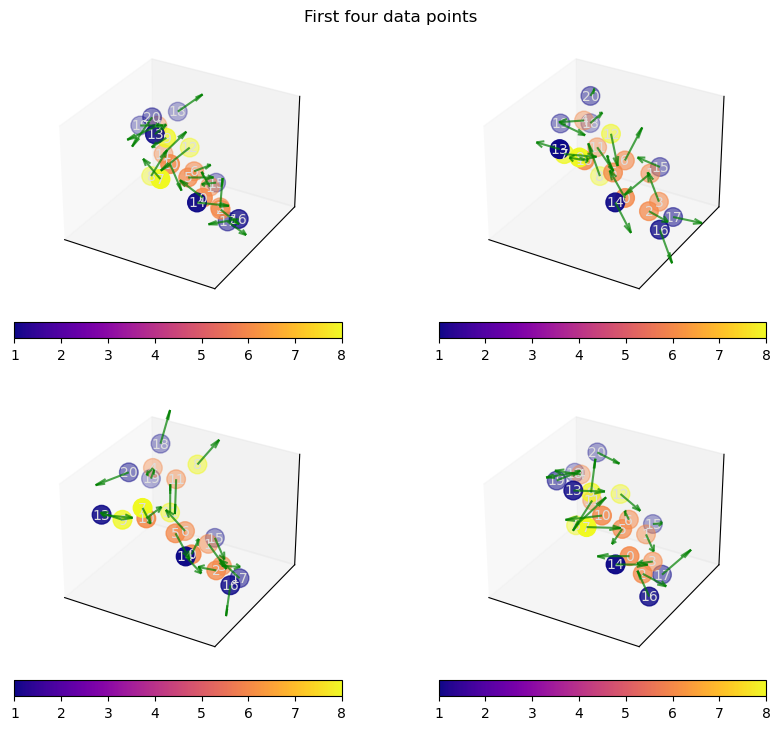

In [8]:
# modified from Volkamerlab

def to_perceived_brightness(rgb: np.ndarray) -> np.ndarray:
    """
    Auxiliary function, useful for choosing label colors
    with good visibility
    """
    r, g, b = rgb
    return 0.1 * r + 0.8 * g + 0.1


def plot_point_cloud_and_vectors_3d(
    fig: mpl.figure.Figure,
    ax_pos: int,
    color: np.ndarray,
    pos: np.ndarray,
    vectors: np.ndarray,
    cmap: str = "plasma",
    point_size: float = 180.0,
    label_axes: bool = False,
    annotate_points: bool = True,
    remove_axes_ticks: bool = True,
    cbar_label: str = "",
) -> mpl.axis.Axis:
    """Visualize colored 3D point clouds.

    Parameters
    ----------
    fig : mpl.figure.Figure
        The figure for which a new axis object is added for plotting
    ax_pos : int
        Three-digit integer specifying axis layout and position
        (see docs for `mpl.figure.Figure.add_subplot`)
    color : np.ndarray
        The point colors as a float array of shape `(N,)`
    pos : np.ndarray
        The point xyz-coordinates as an array
    vectors : np.ndarray
        The vectors from each xyz coordinate as an array
    cmap : str, optional
        String identifier for a matplotlib colormap.
        Is used to map the values in `color` to rgb colors.
        , by default "plasma"
    point_size : float, optional
        The size of plotted points, by default 180.0
    label_axes : bool, optional
        whether to label x,y and z axes by default False
    annotate_points : bool, optional
        whether to label points with their index, by default True
    cbar_label : str, optional
        label for the colorbar, by default ""

    Returns
    -------
    mpl.axis.Axis
        The new axis object for the 3D point cloud plot.
    """
    cmap = plt.get_cmap(cmap)
    ax = fig.add_subplot(ax_pos, projection="3d")
    x, y, z = pos
    u, v, w = pos + vectors

    sc = ax.scatter(x, y, z, c=color, cmap=cmap, s=point_size)
    ax.quiver(x, y, z, u, v, w, length=1.5, normalize=True, color="green", alpha=0.7)

    if remove_axes_ticks:
        # ax.set_xticklabels([])
        # ax.set_yticklabels([])
        # ax.set_zticklabels([])
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])
    if label_axes:
        ax.set_xlabel("$x$")
        ax.set_ylabel("$y$")
        ax.set_zlabel("$z$")

    plt.colorbar(sc, location="bottom", shrink=0.6, anchor=(0.5, 2), label=cbar_label)
    if annotate_points:
        _colors = sc.cmap(color)
        rgb = _colors[:, :3].transpose()
        brightness = to_perceived_brightness(rgb)
        for i, (xi, yi, zi, li) in enumerate(zip(x, y, z, brightness)):
            ax.text(xi, yi, zi, str(i), None, color=[1 - li] * 3, ha="center", va="center")
    return ax


# testing
fig = plt.figure(figsize=(10, 8))

for i, ax_pos in enumerate([221, 222, 223, 224]):
    pos = train_md17[i].pos.T
    vectors = train_md17[i].force.T  
    color = train_md17[i].z
    plot_point_cloud_and_vectors_3d(fig, ax_pos, color, pos, vectors)

fig.suptitle("First four data points")

fig.tight_layout()
plt.show()

In [9]:
# stolen from Volkamerlab

# use rotations along z-axis as demo e(3) transformation
def rotation_matrix_z(theta: float) -> Tensor:
    """Generates a rotation matrix and returns
    a corresponing tensor. The rotation is about the $z$-axis.
    (https://en.wikipedia.org/wiki/Rotation_matrix)

    Parameters
    ----------
    theta : float
        the angle of rotation in radians.

    Returns
    -------
    Tensor
        the rotation matrix as float tensor.
    """
    return torch.tensor(
        [
            [math.cos(theta), -math.sin(theta), 0],
            [math.sin(theta), math.cos(theta), 0],
            [0, 0, 1],
        ]
    )


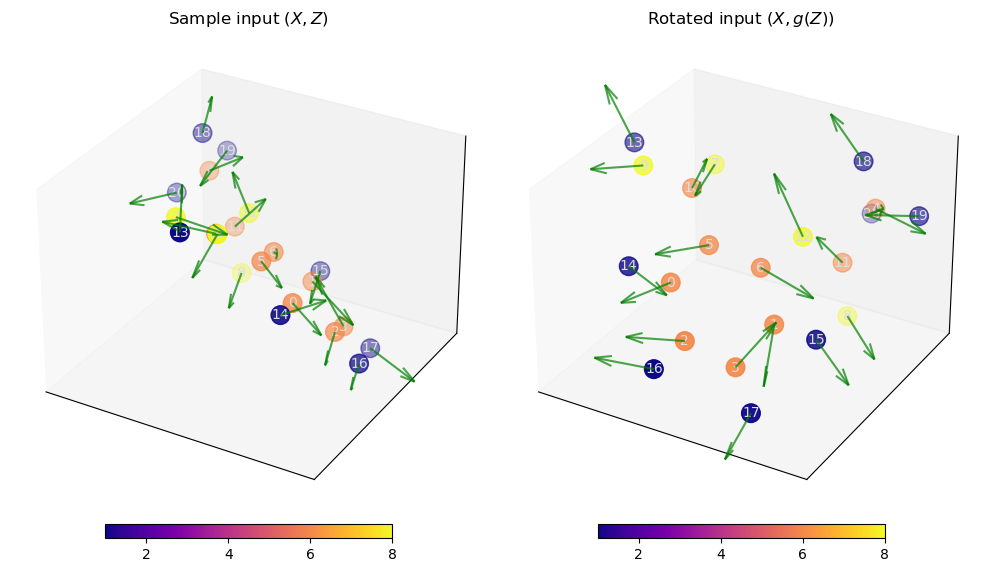

In [10]:
# Some data point
sample_data = train_md17[800].clone()

# apply an E(3) transformation
rotated_sample_data = sample_data.clone()

deg = 90
theta = deg * (math.pi / 180)
rotated_sample_data.pos = rotated_sample_data.pos @ rotation_matrix_z(theta)
rotated_sample_data.force = rotated_sample_data.force @ rotation_matrix_z(theta)

# make a plot that demonstrates rotation
fig = plt.figure(figsize=(10, 8))

ax1 = plot_point_cloud_and_vectors_3d(fig, 121, sample_data.z, sample_data.pos.T, sample_data.force.T)
ax1.set_title("Sample input $(X, Z)$")

ax2 = plot_point_cloud_and_vectors_3d(fig, 122, rotated_sample_data.z, rotated_sample_data.pos.T, rotated_sample_data.force.T)
ax2.set_title("Rotated input $(X, g(Z))$")

fig.tight_layout()
plt.show()

In [11]:
MAP_Z_TO_ATOMIC_MASS = {
        1: 1.0080,
        6: 12.011,
        8: 15.999
    }

MASSES_ASPIRIN_ATOMS = torch.tensor([MAP_Z_TO_ATOMIC_MASS[z.item()] for z in train_md17[0].z], dtype=torch.float)
TOTAL_MASS_ASPIRIN = MASSES_ASPIRIN_ATOMS.sum()

def get_center_of_mass(data: data.Data):
    x, y, z = data.pos.T

    total_x_mass = torch.sum(x * MASSES_ASPIRIN_ATOMS)
    total_y_mass = torch.sum(y * MASSES_ASPIRIN_ATOMS)
    total_z_mass = torch.sum(z * MASSES_ASPIRIN_ATOMS)

    center_of_mass = torch.tensor([total_x_mass/TOTAL_MASS_ASPIRIN, 
                                   total_y_mass/TOTAL_MASS_ASPIRIN, 
                                   total_z_mass/TOTAL_MASS_ASPIRIN], dtype=torch.float).view((1, -1))

    return center_of_mass

def center_datapoint(data: data.Data):
    data.pos = data.pos - get_center_of_mass(data)
    return data

In [12]:
train_md17[0].pos

tensor([[ 2.1345, -0.9844, -0.1952],
        [ 0.7626,  0.9594, -1.6799],
        [ 2.6603, -0.4079, -1.3073],
        [ 1.9103,  0.3940, -2.1470],
        [-3.0302,  1.4954,  0.7197],
        [ 0.8494, -0.5509,  0.2844],
        [ 0.2384,  0.4735, -0.4044],
        [ 0.8979, -2.2764,  1.7301],
        [-2.3835,  0.4178, -1.4629],
        [-0.4762, -0.5291,  2.3393],
        [ 0.3930, -1.1902,  1.5380],
        [-2.1230,  0.9518, -0.3977],
        [-0.8047,  1.2862,  0.1105],
        [-0.4938, -1.1868,  3.0960],
        [ 2.5547, -1.8025,  0.3921],
        [ 0.3307,  1.8557, -2.3453],
        [ 3.8038, -0.4937, -1.4562],
        [ 2.2311,  0.5572, -3.1241],
        [-2.7089,  2.4847,  0.9269],
        [-4.1305,  1.4822,  0.4313],
        [-2.8741,  1.0032,  1.6995]])

In [13]:
get_center_of_mass(train_md17[0])

tensor([[ 1.6775e-04,  4.8446e-05, -1.5794e-04]])

In [14]:
center_datapoint(train_md17[0]).pos  # as pre_transform

tensor([[ 2.1343, -0.9844, -0.1951],
        [ 0.7625,  0.9594, -1.6798],
        [ 2.6602, -0.4080, -1.3071],
        [ 1.9101,  0.3939, -2.1469],
        [-3.0304,  1.4954,  0.7198],
        [ 0.8493, -0.5509,  0.2845],
        [ 0.2383,  0.4735, -0.4043],
        [ 0.8977, -2.2765,  1.7302],
        [-2.3836,  0.4177, -1.4627],
        [-0.4764, -0.5291,  2.3394],
        [ 0.3928, -1.1903,  1.5381],
        [-2.1232,  0.9517, -0.3975],
        [-0.8048,  1.2862,  0.1107],
        [-0.4940, -1.1868,  3.0961],
        [ 2.5546, -1.8025,  0.3923],
        [ 0.3305,  1.8557, -2.3451],
        [ 3.8036, -0.4938, -1.4560],
        [ 2.2310,  0.5571, -3.1240],
        [-2.7091,  2.4846,  0.9271],
        [-4.1307,  1.4821,  0.4314],
        [-2.8743,  1.0032,  1.6996]])

In [19]:
# edges

train_loader = loader.DataLoader(train_md17, shuffle=True, batch_size=32)
batch = next(iter(train_loader))
batch

DataBatch(pos=[672, 3], z=[672], energy=[32], force=[672, 3], batch=[672], ptr=[33])

In [20]:
edge_index = geometric_nn.knn_graph(batch.pos, 5, batch.batch)
edge_index

ImportError: 'knn_graph' requires 'torch-cluster'

In [ ]:
class SphericalEGNN(nn.Module):
    def __init__(self,
                 hid_dim: int,
                 pos_size: int = 3,
                 ):
        super().__init__()

        self.initial_embed = nn.Embedding(100, hid_dim)

    def split_positional_vector(self, pos: Tensor) -> tuple[Tensor]:
        radial_part = torch.linalg.norm(pos, dim=1)
        directional_part = pos / radial_part

        return radial_part, directional_part
    
    

In [240]:
train_md17[:10].z

tensor([6, 6, 6, 6, 6, 6, 6, 8, 8, 8, 6, 6, 8, 1, 1, 1, 1, 1, 1, 1, 1, 6, 6, 6,
        6, 6, 6, 6, 8, 8, 8, 6, 6, 8, 1, 1, 1, 1, 1, 1, 1, 1, 6, 6, 6, 6, 6, 6,
        6, 8, 8, 8, 6, 6, 8, 1, 1, 1, 1, 1, 1, 1, 1, 6, 6, 6, 6, 6, 6, 6, 8, 8,
        8, 6, 6, 8, 1, 1, 1, 1, 1, 1, 1, 1, 6, 6, 6, 6, 6, 6, 6, 8, 8, 8, 6, 6,
        8, 1, 1, 1, 1, 1, 1, 1, 1, 6, 6, 6, 6, 6, 6, 6, 8, 8, 8, 6, 6, 8, 1, 1,
        1, 1, 1, 1, 1, 1, 6, 6, 6, 6, 6, 6, 6, 8, 8, 8, 6, 6, 8, 1, 1, 1, 1, 1,
        1, 1, 1, 6, 6, 6, 6, 6, 6, 6, 8, 8, 8, 6, 6, 8, 1, 1, 1, 1, 1, 1, 1, 1,
        6, 6, 6, 6, 6, 6, 6, 8, 8, 8, 6, 6, 8, 1, 1, 1, 1, 1, 1, 1, 1, 6, 6, 6,
        6, 6, 6, 6, 8, 8, 8, 6, 6, 8, 1, 1, 1, 1, 1, 1, 1, 1])